# Banka Müşteri Churn Tahmini — Modelleme

Bu notebook'ta üç farklı sınıflandırma algoritması karşılaştırılmaktadır: **Random Forest**, **Gradient Boosting** ve **LightGBM**.
Modeller önce ham eğitim verisi üzerinde, ardından **SMOTE** ile dengelenmiş veri üzerinde eğitilmektedir.
Sınıf dengesizliğinin model performansına etkisi incelenmekte; en iyi kombinasyon hata matrisi ile değerlendirilmektedir.

> Bu notebook `2_preprocessing.ipynb` çıktılarını (X, y) kullanmaktadır. Bağımsız çalıştırmak için ön işleme adımları aşağıya dahil edilmiştir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

pd.set_option('display.max_columns', None)

# Veri yükleme
churn = pd.read_csv('Churn.csv')
df = churn.copy()

# Encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df[['Geography_Germany', 'Geography_Spain', 'Gender_Male']] = df[['Geography_Germany', 'Geography_Spain', 'Gender_Male']].astype(int)

# Feature engineering
df1 = df.copy()
df1.loc[(df1['Age']>=18) & (df1['Age']<=30), 'Age'] = 1
df1.loc[(df1['Age']>30) & (df1['Age']<=40), 'Age'] = 2
df1.loc[(df1['Age']>40) & (df1['Age']<=50), 'Age'] = 3
df1.loc[(df1['Age']>50) & (df1['Age']<=60), 'Age'] = 4
df1.loc[(df1['Age']>60) & (df1['Age']<=92), 'Age'] = 5

def kredi_skor_tablosu(row):
    k = row.CreditScore
    if k < 300: return 1
    elif k < 500: return 2
    elif k < 601: return 3
    elif k < 661: return 4
    elif k < 781: return 5
    elif k < 851: return 6
    else: return 7

df1 = df1.assign(credit_score_table=df1.apply(lambda x: kredi_skor_tablosu(x), axis=1))

df1['retired'] = df['Age']
df1.loc[(df1['retired']>=65) & (df1['Geography_Germany']==1), 'retired'] = 1
df1.loc[(df1['retired']>=65) & (df1['Geography_Spain']==1), 'retired'] = 1
df1.loc[(df1['retired']>=66) & (df['Geography_Spain']==0) & (df['Geography_Germany']==0), 'retired'] = 1
df1.loc[(df1['retired']<65) & (df1['Geography_Germany']==1), 'retired'] = 0
df1.loc[(df1['retired']<65) & (df1['Geography_Spain']==1), 'retired'] = 0
df1.loc[(df1['retired']<66) & (df['Geography_Spain']==0) & (df['Geography_Germany']==0), 'retired'] = 0
df1['Tenure/NumOfProducts'] = df1['Tenure'] / df1['NumOfProducts']

df1['smallerthan405'] = df['CreditScore']
df1.loc[df1['smallerthan405'] < 405, 'smallerthan405'] = 1
df1.loc[df1['smallerthan405'] > 405, 'smallerthan405'] = 0

df1['NOP*'] = df['NumOfProducts']
df1.loc[df1['NOP*'] == 2, 'NOP*'] = 1
df1.loc[df1['NOP*'] == 1, 'NOP*'] = 2
df1.loc[df1['NOP*'] > 2, 'NOP*'] = 3

df1['Balance0'] = df1['Balance']
df1.loc[df1['Balance0'] == 0, 'Balance0'] = 0
df1.loc[df1['Balance0'] != 0, 'Balance0'] = 1

df1['ES/Age'] = df1['EstimatedSalary'] / (df['Age'] - 17)
df1['Tenure/Age'] = df1['Tenure'] / (df['Age'] - 17)
df1['Balance/ES'] = df1['Balance'] / df1['EstimatedSalary']
df1['EstimatedSalary'] = df1['EstimatedSalary'] / 12
df1['ES/Tenure'] = df1['EstimatedSalary'] / (df1['Tenure'] + 1)
df1['ES/Score'] = df1['EstimatedSalary'] / df1['credit_score_table']
df1 = df1.drop(['CreditScore', 'Tenure', 'Balance'], axis=1)

# Scaling
df1_num = df1[['Age', 'NumOfProducts', 'EstimatedSalary',
               'credit_score_table', 'Tenure/NumOfProducts', 'NOP*',
               'ES/Age', 'Tenure/Age', 'Balance/ES', 'ES/Tenure', 'ES/Score']]
col = df1_num.columns
x_transformed = pd.DataFrame(RobustScaler().fit(df1_num).transform(df1_num), columns=col)

X = pd.concat([
    x_transformed.loc[:, 'Age':'NumOfProducts'],
    df1.loc[:, 'HasCrCard':'IsActiveMember'],
    x_transformed.loc[:, 'EstimatedSalary'],
    df1.loc[:, 'Geography_Germany':'Gender_Male'],
    x_transformed.loc[:, 'credit_score_table'],
    df1.loc[:, 'retired'],
    x_transformed.loc[:, 'Tenure/NumOfProducts'],
    df1.loc[:, 'smallerthan405'],
    x_transformed.loc[:, 'NOP*'],
    df1.loc[:, 'Balance0'],
    x_transformed.loc[:, 'ES/Age':'ES/Score']
], axis=1)

y = df1['Exited']
print("Veri hazır. X shape:", X.shape)

Veri hazır. X shape: (10000, 19)


## 4. Temel Modelleme (SMOTE Öncesi)

Modeller önce orijinal, dengesiz veri seti üzerinde eğitilerek temel performans ölçümleri alınmaktadır.

In [2]:
# Veri setini eğitim (%80) ve test (%20) olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12345)

### 4.1 Random Forest

Varsayılan hiperparametrelerle eğitilmiş Random Forest modeli. 10-katlı çapraz doğrulama ile CV doğruluğu raporlanmaktadır.

In [3]:
rf_model = RandomForestClassifier(random_state=12345).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

cv_results = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='accuracy')
print('CV Doğruluk:', cv_results.mean())
print('Test Doğruluk:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CV Doğruluk: 0.853125
Test Doğruluk: 0.8455
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1573
           1       0.74      0.42      0.54       427

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.83      0.85      0.83      2000



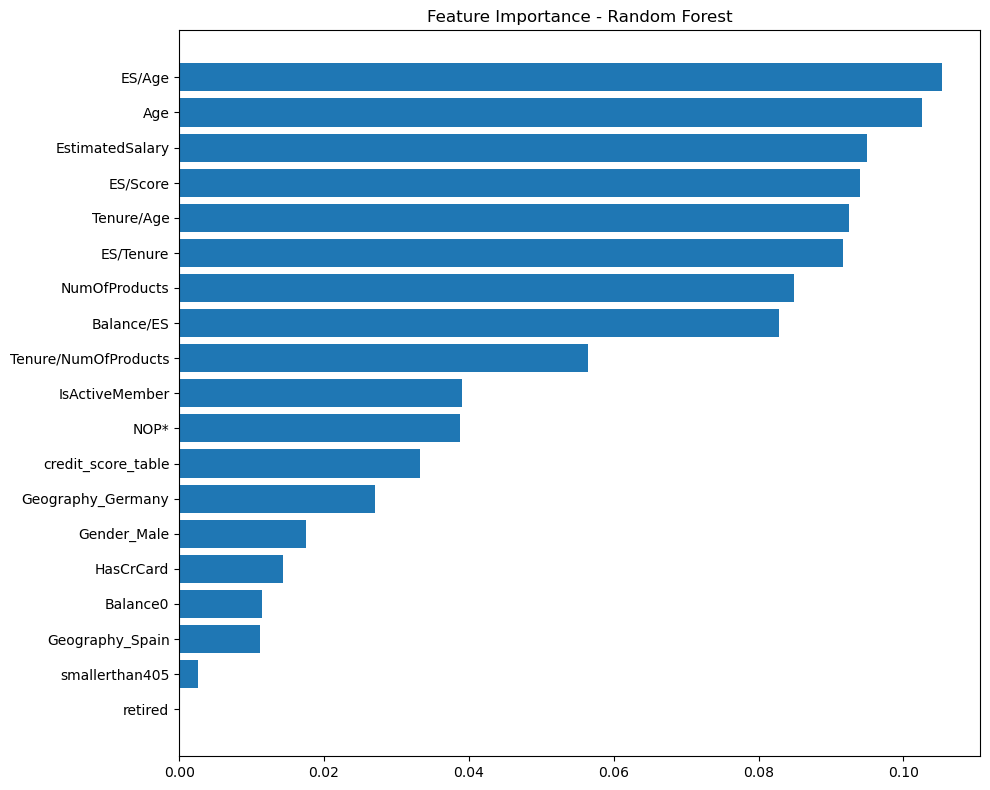

In [4]:
importance = rf_model.feature_importances_
# Önem değerlerine göre sırala
sorted_idx = np.argsort(importance)
plt.figure(figsize=(10, 8))
plt.barh(X.columns[sorted_idx], importance[sorted_idx])
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

### 4.2 Gradient Boosting

Varsayılan hiperparametrelerle eğitilmiş Gradient Boosting modeli.

In [5]:
gbm_model = GradientBoostingClassifier(random_state=12345).fit(X_train, y_train)
y_pred = gbm_model.predict(X_test)

cv_results = cross_val_score(gbm_model, X_train, y_train, cv=10, scoring='accuracy')
print('CV Doğruluk:', cv_results.mean())
print('Test Doğruluk:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CV Doğruluk: 0.8629999999999999
Test Doğruluk: 0.853
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1573
           1       0.79      0.43      0.55       427

    accuracy                           0.85      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.85      0.84      2000



### 4.3 LightGBM

Varsayılan hiperparametrelerle eğitilmiş LightGBM modeli. `verbose=-1` ile eğitim logları bastırılmıştır.
Hiperparametre araması yapılmış ancak varsayılan değerlerin üzerinde anlamlı bir iyileştirme sağlanamamıştır.

In [6]:
lgbm_model = LGBMClassifier(random_state=12345, verbose=-1).fit(X_train, y_train)
y_pred = lgbm_model.predict(X_test)

cv_results = cross_val_score(lgbm_model, X_train, y_train, cv=10, scoring='accuracy')
print('CV Doğruluk:', cv_results.mean())
print('Test Doğruluk:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CV Doğruluk: 0.85775
Test Doğruluk: 0.858
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1573
           1       0.78      0.47      0.58       427

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.84      2000



## 5. Sınıf Dengesizliği ve SMOTE

Veri setindeki yaklaşık **%20/%80** (churn / kalmış) dağılımı, modellerin azınlık sınıfını (churn) öğrenmesini zorlaştırmaktadır. Bu bölümde **SMOTE** (Synthetic Minority Oversampling Technique) uygulanarak eğitim seti sentetik örneklerle dengelenmekte, ardından Random Forest ve LightGBM modelleri bu dengeli veri üzerinde yeniden eğitilmektedir.

> **Not:** SMOTE yalnızca **eğitim setine** uygulanmaktadır; test seti her zaman orijinal dağılımında kalmaktadır.

In [7]:
smt = SMOTE(random_state=12345)

print('SMOTE öncesi train dağılımı:', Counter(y_train))
X_res, y_res = smt.fit_resample(X_train, y_train)
print('SMOTE sonrası train dağılımı:', Counter(y_res))
print('Test seti değişmedi:', Counter(y_test))

SMOTE öncesi train dağılımı: Counter({0: 6390, 1: 1610})
SMOTE sonrası train dağılımı: Counter({0: 6390, 1: 6390})
Test seti değişmedi: Counter({0: 1573, 1: 427})


### 5.1 Random Forest + SMOTE

SMOTE ile dengelenmiş `X_res` / `y_res` üzerinde eğitilen Random Forest modeli. Aşırı öğrenme kontrolü için hem eğitim hem test doğruluğu raporlanmaktadır.

In [8]:
# X_res, y_res: SMOTE uygulanmış train seti
# X_test, y_test: orijinal, dokunulmamış test seti
rf_smote_model = RandomForestClassifier(random_state=12345).fit(X_res, y_res)
y_pred_rf = rf_smote_model.predict(X_test)

cv_rf = cross_val_score(rf_smote_model, X_res, y_res, cv=10, scoring='accuracy')

print('CV Doğruluk:', cv_rf.mean())
print('Test Doğruluk:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

CV Doğruluk: 0.9022691705790298
Test Doğruluk: 0.8195
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1573
           1       0.58      0.54      0.56       427

    accuracy                           0.82      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.82      0.82      0.82      2000



### 5.2 LightGBM + SMOTE

SMOTE ile dengelenmiş `X_res` / `y_res` üzerinde eğitilen LightGBM modeli. Sonuç tablosuna göre en yüksek test doğruluğuna ulaşan modeldir.

In [9]:
# X_res, y_res: SMOTE uygulanmış train seti
# X_test, y_test: orijinal, dokunulmamış test seti
lgbm_model = LGBMClassifier(random_state=12345, verbose=-1).fit(X_res, y_res)
y_pred = lgbm_model.predict(X_test)

cv_train = cross_val_score(lgbm_model, X_res, y_res, cv=10, scoring='accuracy')

print('CV Doğruluk:', cv_train.mean())
print('Test Doğruluk:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CV Doğruluk: 0.8923317683881062
Test Doğruluk: 0.8465
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1573
           1       0.67      0.55      0.60       427

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



### 5.3 Hata Matrisi

En iyi performansı gösteren **LightGBM + SMOTE** modeline ait hata matrisi. Hücreler oransal olarak gösterilmektedir (toplam tahmin sayısına bölünmüş).

[[1458  115]
 [ 192  235]]


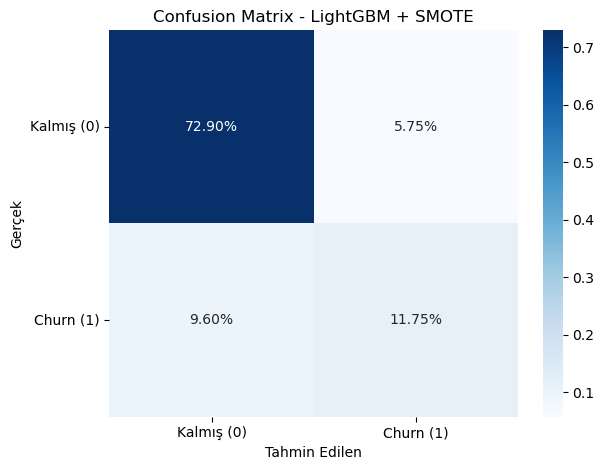

In [10]:
cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)

ax = sns.heatmap(cf_matrix / np.sum(cf_matrix), annot=True,
                 fmt='.2%', cmap='Blues')
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gerçek')
ax.set_xticklabels(['Kalmış (0)', 'Churn (1)'])
ax.set_yticklabels(['Kalmış (0)', 'Churn (1)'], rotation=0)
plt.title('Confusion Matrix - LightGBM + SMOTE')
plt.tight_layout()
plt.show()

## 6. Sonuç ve Değerlendirme

SMOTE uygulanmış veri seti üzerinde eğitilen Random Forest ve LightGBM modelleri birbirine yakın performans sergilemiştir.

En iyi sonuç **LightGBM + SMOTE** kombinasyonundan elde edilmiştir. SMOTE uygulaması tüm modellerde azınlık sınıfı (churn) için **recall** değerini belirgin biçimde artırmıştır.